In [47]:
import pandas as pd
from pathlib import Path
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, skew, kurtosis, norm
from scipy.stats import pearsonr
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from linearmodels.panel import RandomEffects
from linearmodels.panel import PanelOLS

In [ ]:
# loading in my data frame classic first steps same as the other part in part 1 

final_data_path = Path("/Users/lorenzouberti/Desktop/Panel-Data-Project-Financial-Econometrics/Data")
df_Final = pd.read_excel(final_data_path / "final_panel_dataset.xlsx")

# In the study as one of teh explanatory varibles they create a 5 year lagged GDP per capita variable.
# Therefore, prior to plotting the distributions, we create this variable in the final data set.

df_Final = df_Final.sort_values(["country", "year"])
df_Final = df_Final[['country', 'year', 'gdppc', 'labour_productivity', 'cpi', 'trade_openness', 'liquid_liabilities', 'mcap_gdp', 'bank_loans_gdp']]
df_Final = df_Final.sort_values(["country", "year"])

# Logging GDP per capita first
df_Final['ln_gdppc'] = np.log(df_Final['gdppc'])
df_Final["ln_gdppc_lag5"] = df_Final.groupby("country")["ln_gdppc"].shift(5)
# Creating the 5 year lagged GDP per capita growth variable
df_Final["ln_gdp_growth_5y"] = df_Final["ln_gdppc"] - df_Final["ln_gdppc_lag5"]

# Doing of rthe alternative dependent variable: labour productivity growth
df_Final['ln_labour_productivity'] = np.log(df_Final['labour_productivity'])
df_Final["ln_labour_productivity_lag5"] = df_Final.groupby("country")["ln_labour_productivity"].shift(5)
df_Final["ln_labour_productivity_growth_5y"] = df_Final["ln_labour_productivity"] - df_Final["ln_labour_productivity_lag5"]

# taking teh logarithm of the other variables as well
df_Final['ln_cpi'] = np.log(df_Final['cpi'])
df_Final['ln_trade_openness'] = np.log(df_Final['trade_openness'])


variables = [ 'ln_gdppc','ln_labour_productivity', 'ln_cpi', 'ln_trade_openness', 'liquid_liabilities', 'mcap_gdp', 'bank_loans_gdp', "ln_gdp_growth_5y", "ln_labour_productivity_growth_5y" ]

for var in variables:   # Between transformation
    df_Final[f'{var}_between'] = df_Final.groupby('country')[var].transform('mean')
    
    # One-way Within transformation
    df_Final[f'{var}_within'] = df_Final[var] - df_Final.groupby('country')[var].transform('mean')

rows = []

# Defining my Dependent and Explanatory Variables
Dependent_Variables_Growth = ['ln_gdp_growth_5y','ln_labour_productivity_growth_5y' ]
Explanatory_Variables = ['ln_gdppc_lag5', 'ln_labour_productivity_lag5', 'liquid_liabilities', 'mcap_gdp', 'bank_loans_gdp']
Control_Variables = ['ln_cpi', 'ln_trade_openness']

individuals = df_Final['country']
time = df_Final['year']
dep_var_col = 'ln_gdp_growth_5y'
exp_var_col = 'liquid_liabilities'
cols_to_keep = ["country", "year", dep_var_col, exp_var_col, "ln_cpi", "ln_trade_openness"]
df_Final_defined = df_Final[cols_to_keep].dropna()

df_Final_defined["dep_var_col_mean_i"] = df_Final_defined.groupby(individuals)[dep_var_col].transform("mean")
df_Final_defined["exp_var_col_mean_i"] = df_Final_defined.groupby(individuals)[exp_var_col].transform("mean")

df_Final_defined["dep_var_col_within"] = df_Final_defined[dep_var_col] - df_Final_defined['dep_var_col_mean_i']
df_Final_defined["exp_var_col_within"] = df_Final_defined[exp_var_col] - df_Final_defined['exp_var_col_mean_i']

between_df_Final_defined = (
    df_Final_defined
    .groupby("country")
    .agg(
        dep_var_col_between=(dep_var_col, 'mean'),
        exp_var_col_between=(exp_var_col, 'mean')
    )
    .reset_index()
)

# TWFE transformation
df_twfe = df_Final.copy()


id_col = "country"
time_col = "year"
cols_twfe = ["liquid_liabilities","mcap_gdp","bank_loans_gdp","ln_gdp_growth_5y","ln_labour_productivity_growth_5y", "ln_cpi", "ln_trade_openness"]
for col in cols_twfe:
    mi = df_twfe.groupby(id_col)[col].transform("mean")
    mt = df_twfe.groupby(time_col)[col].transform("mean")
    mall = df_twfe[col].mean()
    df_twfe[col + "_twfe"] = df_twfe[col] - mi - mt + mall

# all the the data witgh the respecive data frame is on df_TWFE



Question 20

In [22]:
id_col = "country"
time_col = "year"

dep_var = "ln_gdp_growth_5y"
x_vars = ["ln_gdppc_lag5", "liquid_liabilities", "mcap_gdp", "bank_loans_gdp"]
control_vars = ["ln_cpi", "ln_trade_openness"]

VIF_cutoff = 10.0
cluster = True  

# variance inflation factor calculation
def calculate_vif(df, features):
    """
    Return a pandas Series indexed by variable name with VIF values.
    The constant (if present) is dropped.
    """
    X = df[features]
    X = sm.add_constant(X, has_constant="add")
    vals = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    cols = list(X.columns)
    vif_series = pd.Series(vals, index=cols, name="VIF")
    # drop the constant entry if present
    if "const" in vif_series.index:
        vif_series = vif_series.drop("const")
    else:
        # also drop first element as a fallback (older usage)
        vif_series = vif_series.iloc[1:] if len(vif_series) > 0 else vif_series
    return vif_series

def drop_high_vif(X: pd.DataFrame, vif_cut: float, keep: set = None, verbose: bool = True):
    if keep is None:
        keep = set()

    Xw = X.copy()

    while True:
        # pass features correctly
        v = calculate_vif(Xw, list(Xw.columns))

        droppable = [c for c in Xw.columns if c not in keep]
        if not droppable:
            break

        v_droppable = v.reindex(droppable).astype(float)
        worst = v_droppable.idxmax()
        worst_val = v_droppable.loc[worst]

        if np.isfinite(worst_val) and worst_val > vif_cut:
            if verbose:
                print(f"    [VIF] dropping '{worst}' (VIF={worst_val:.2f} > {vif_cut})")
            Xw = Xw.drop(columns=[worst])
        else:
            break

    return Xw, calculate_vif(Xw, list(Xw.columns))


def fit_ols(y: pd.Series, X: pd.DataFrame, clusters: pd.Series = None, add_const: bool = False):
    X_use = sm.add_constant(X, has_constant="add") if add_const else X
    model = sm.OLS(y.astype(float).values, X_use.astype(float).values)
    if clusters is not None:
        res = model.fit(cov_type="cluster", cov_kwds={"groups": clusters.values})
    else:
        res = model.fit()
    res.X_names = list(X_use.columns)
    return res


def short_print(title: str, res):
    print("\n" + "="*80)
    print(title)
    print("-"*80)
    params = pd.Series(res.params, index=res.X_names)
    print(params)
    print(f"\n nobs={int(res.nobs)}  R2={getattr(res,'rsquared',np.nan):.4f}")
    print("="*80)


def fisher_test_fe(df_levels: pd.DataFrame, y: str, X_cols: list):
    d = df_levels[[id_col, y] + X_cols].dropna().copy()

    # Force numeric in X and y (Excel sometimes loads as object)
    for c in [y] + X_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d.dropna(subset=[y] + X_cols)

    # pooled (restricted)
    X_r = sm.add_constant(d[X_cols], has_constant="add").astype(float)
    yv = d[y].astype(float).values
    res_r = sm.OLS(yv, X_r.values).fit()

    # LSDV (unrestricted)
    dums = pd.get_dummies(d[id_col], drop_first=True, prefix="fe", dtype=float)
    X_u = pd.concat([X_r, dums], axis=1).astype(float)

    res_u = sm.OLS(yv, X_u.values).fit()

    q = dums.shape[1]
    n = len(d)
    k_u = X_u.shape[1]
    F = ((res_r.ssr - res_u.ssr) / q) / (res_u.ssr / (n - k_u))
    p = 1 - stats.f.cdf(F, q, n - k_u)
    return {"F": float(F), "df1": int(q), "df2": int(n - k_u), "p": float(p)}


def ancova_poolability_test(df_levels: pd.DataFrame, y: str, X_cols: list, add_time_fe: bool = False):
    """
    ANCOVA / poolability test (common slopes):
    H0: no entity*X interactions (common slopes)
    """
    d = df_levels[[id_col, time_col, y] + X_cols].dropna().copy()

    # Force numeric in X and y
    for c in [y] + X_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # Make sure time is safe for dummies
    d[time_col] = pd.to_numeric(d[time_col], errors="coerce")
    d = d.dropna(subset=[time_col, y] + X_cols)

    Xbase = sm.add_constant(d[X_cols], has_constant="add").astype(float)
    fe = pd.get_dummies(d[id_col], drop_first=True, prefix="fe", dtype=float)

    parts = [Xbase, fe]

    if add_time_fe:
        te = pd.get_dummies(d[time_col].astype(int), drop_first=True, prefix="t", dtype=float)
        parts.append(te)

    X_base = pd.concat(parts, axis=1).astype(float)

    # interactions fe*X
    inter_blocks = []
    for x in X_cols:
        inter_blocks.append(fe.mul(d[x].astype(float), axis=0))
    X_inter = pd.concat(inter_blocks, axis=1).astype(float)
    X_inter.columns = [f"{c}#c.{x}" for x in X_cols for c in fe.columns]

    X_unres = pd.concat([X_base, X_inter], axis=1).astype(float)

    yv = d[y].astype(float).values
    res_base = sm.OLS(yv, X_base.values).fit()
    res_unres = sm.OLS(yv, X_unres.values).fit()

    q = X_inter.shape[1]
    n = len(d)
    k_u = X_unres.shape[1]
    F = ((res_base.ssr - res_unres.ssr) / q) / (res_unres.ssr / (n - k_u))
    p = 1 - stats.f.cdf(F, q, n - k_u)
    return {"F": float(F), "df1": int(q), "df2": int(n - k_u), "p": float(p), "time_fe": add_time_fe}



def chow_group_test(df_levels: pd.DataFrame, y: str, X_cols: list, group_col: str):
    d = df_levels[[y, group_col] + X_cols].dropna().copy()
    g = d[group_col].astype(float)

    X0 = sm.add_constant(d[X_cols], has_constant="add")
    inter = pd.concat([(g * d[x]).rename(f"{group_col}*{x}") for x in X_cols], axis=1)
    X = pd.concat([X0, g.rename(group_col), inter], axis=1)

    res = sm.OLS(d[y].values, X.values).fit()

    # Wald test all interaction coeffs = 0
    k0 = X0.shape[1] + 1  # const + X + g
    R = np.zeros((len(X_cols), X.shape[1]))
    for i in range(len(X_cols)):
        R[i, k0 + i] = 1.0
    wald = res.wald_test(R)
    return {"chi2": float(wald.statistic), "df": len(X_cols), "p": float(wald.pvalue)}

def chow_time_break(df_levels: pd.DataFrame, y: str, X_cols: list, break_year: int):
    d = df_levels[[time_col, y] + X_cols].dropna().copy()
    X_full = sm.add_constant(d[X_cols], has_constant="add")
    res_full = sm.OLS(d[y].values, X_full.values).fit()

    d1 = d[d[time_col] < break_year]
    d2 = d[d[time_col] >= break_year]
    X1 = sm.add_constant(d1[X_cols], has_constant="add")
    X2 = sm.add_constant(d2[X_cols], has_constant="add")
    res1 = sm.OLS(d1[y].values, X1.values).fit()
    res2 = sm.OLS(d2[y].values, X2.values).fit()

    SSR_pooled = res_full.ssr
    SSR_split  = res1.ssr + res2.ssr
    k = X_full.shape[1]
    n1, n2 = len(d1), len(d2)

    F = ((SSR_pooled - SSR_split) / k) / (SSR_split / (n1 + n2 - 2*k))
    p = 1 - stats.f.cdf(F, k, (n1 + n2 - 2*k))
    return {"F": F, "df1": k, "df2": (n1 + n2 - 2*k), "p": p, "break_year": break_year}

# Build X_ALL from existing variable lists if not already present
if 'X_ALL' not in globals():
    # prefer explicit lists already in the notebook
    try:
        X_ALL = Explanatory_Variables + Control_Variables
    except NameError:
        # fallback: try other common names
        X_ALL = x_vars + control_vars

else:
    # ensure control vars are included
    try:
        for c in Control_Variables:
            if c not in X_ALL:
                X_ALL.append(c)
    except NameError:
        for c in control_vars:
            if c not in X_ALL:
                X_ALL.append(c)

# Use existing dataframe and column name variables (these exist in the notebook)
df_levels = df_Final[[id_col, time_col, dep_var] + X_ALL].dropna().copy()

# Create backwards-compatible aliases expected by the subsequent code so we don't have to rewrite it
ID_COL = id_col
T_COL = time_col
DEP = dep_var
VIF_CUT = VIF_cutoff
CLUSTER = cluster

# Ensure optional variables exist (do not overwrite if already defined)
if 'GROUP_COL' not in globals():
    GROUP_COL = None
if 'BREAK_YEAR' not in globals():
    BREAK_YEAR = None

# ==========================================================
# 6) GLOBAL TESTS (report once; they pertain to common-slopes pooling)
# ==========================================================
print("\n>>> Fisher FE test (are country effects jointly significant?)")
print(fisher_test_fe(df_levels, DEP, X_ALL))

print("\n>>> ANCOVA / poolability test (common slopes) one-way base")
print(ancova_poolability_test(df_levels, DEP, X_ALL, add_time_fe=False))

print("\n>>> ANCOVA / poolability test (common slopes) two-way base")
print(ancova_poolability_test(df_levels, DEP, X_ALL, add_time_fe=True))

if GROUP_COL is not None:
    print("\n>>> Chow group test (0/1)")
    print(chow_group_test(df_levels, DEP, X_ALL, GROUP_COL))
if BREAK_YEAR is not None:
    print("\n>>> Chow time-break test")
    print(chow_time_break(df_levels, DEP, X_ALL, BREAK_YEAR))


# ==========================================================
# 7) ESTIMATORS
# ==========================================================

# -----------------
# (A) BETWEEN (BE)
# -----------------
print("\n>>> BETWEEN (BE) regression: OLS on country means (includes constant)")
between = df_levels.groupby(ID_COL)[[DEP] + X_ALL].mean().reset_index()

y_be = between[DEP]
X_be_raw = between[X_ALL]

X_be, vif_be = drop_high_vif(X_be_raw, VIF_CUT, verbose=True)
print("  BE regressors kept:", list(X_be.columns))
print("  VIF (BE):\n", vif_be)

res_be = fit_ols(y_be, X_be, clusters=None, add_const=True)
short_print("BETWEEN (BE)", res_be)


# -----------------
# (B) WITHIN / FE
# -----------------
print("\n>>> WITHIN (one-way FE): within-transformed OLS (no constant)")
df_w = df_levels.sort_values([ID_COL, T_COL]).copy()
for c in [DEP] + X_ALL:
    df_w[c + "_within"] = df_w[c] - df_w.groupby(ID_COL)[c].transform("mean")

y_w = df_w[DEP + "_within"]
X_w_raw = df_w[[c + "_within" for c in X_ALL]]

X_w, vif_w = drop_high_vif(X_w_raw, VIF_CUT, verbose=True)
print("  FE(within) regressors kept:", list(X_w.columns))
print("  VIF (FE/within):\n", vif_w)

clusters = df_w[ID_COL] if CLUSTER else None
res_fe = fit_ols(y_w, X_w, clusters=clusters, add_const=False)
short_print("WITHIN / FE (one-way)", res_fe)


# -----------------
# (C) MUNDLAK RE
# -----------------
print("\n>>> MUNDLAK (RE + country means of ALL X): RandomEffects + constant")

df_m = df_levels.sort_values([ID_COL, T_COL]).copy()
for c in X_ALL:
    df_m[c + "_mean_i"] = df_m.groupby(ID_COL)[c].transform("mean")

mundlak_cols = X_ALL + [c + "_mean_i" for c in X_ALL]
X_m_raw = df_m[mundlak_cols]

X_m, vif_m = drop_high_vif(X_m_raw, VIF_CUT, verbose=True)
print("  Mundlak regressors kept:", list(X_m.columns))
print("  VIF (Mundlak):\n", vif_m)

panel_m = df_m.set_index([ID_COL, T_COL])
y_m = panel_m[DEP]
X_m_panel = sm.add_constant(panel_m[X_m.columns], has_constant="add")

re_mod = RandomEffects(y_m, X_m_panel)
re_res = re_mod.fit(cov_type="clustered", cluster_entity=True) if CLUSTER else re_mod.fit()
print(re_res.summary)


# -----------------
# (D) TWO-WAY FE (TWFE)
# -----------------
print("\n>>> TWO-WAY FE: OLS on your TWFE-transformed variables (no constant)")

needed = [DEP] + X_ALL
df_t = df_twfe[[ID_COL, T_COL] + needed].dropna().copy()

# Ensure *_twfe exist; if not, compute quickly
for col in needed:
    if col + "_twfe" not in df_twfe.columns:
        mi = df_t.groupby(ID_COL)[col].transform("mean")
        mt = df_t.groupby(T_COL)[col].transform("mean")
        mall = df_t[col].mean()
        df_t[col + "_twfe"] = df_t[col] - mi - mt + mall
    else:
        df_t[col + "_twfe"] = df_twfe.loc[df_t.index, col + "_twfe"]

y_twfe = df_t[DEP + "_twfe"]
X_twfe_raw = df_t[[c + "_twfe" for c in X_ALL]]

X_twfe, vif_twfe = drop_high_vif(X_twfe_raw, VIF_CUT, verbose=True)
print("  TWFE regressors kept:", list(X_twfe.columns))
print("  VIF (TWFE):\n", vif_twfe)

clusters = df_t[ID_COL] if CLUSTER else None
res_twfe = fit_ols(y_twfe, X_twfe, clusters=clusters, add_const=False)
short_print("TWO-WAY FE (TWFE transform)", res_twfe)


# -----------------
# (E) FIRST DIFFERENCES (FD)
# -----------------
print("\n>>> FIRST DIFFERENCES: Δ-OLS (no constant)")

df_fd = df_levels.sort_values([ID_COL, T_COL]).copy()
for c in [DEP] + X_ALL:
    df_fd["d_" + c] = df_fd.groupby(ID_COL)[c].diff()

df_fd = df_fd.dropna(subset=["d_" + DEP] + ["d_" + c for c in X_ALL]).copy()
y_fd = df_fd["d_" + DEP]
X_fd_raw = df_fd[["d_" + c for c in X_ALL]]

X_fd, vif_fd = drop_high_vif(X_fd_raw, VIF_CUT, verbose=True)
print("  FD regressors kept:", list(X_fd.columns))
print("  VIF (FD):\n", vif_fd)

clusters = df_fd[ID_COL] if CLUSTER else None
res_fd = fit_ols(y_fd, X_fd, clusters=clusters, add_const=False)
short_print("FIRST DIFFERENCES (FD)", res_fd)


# ==========================================================
# 8) ONE COEFFICIENT TABLE (optional)
# ==========================================================
def coef_table():
    def pack_sm(res, name):
        return pd.Series(res.params, index=res.X_names, name=name)

    out = pd.concat([
        pack_sm(res_be, "BE"),
        pack_sm(res_fe, "FE_within"),
        pd.Series(re_res.params, name="Mundlak_RE"),
        pack_sm(res_twfe, "TWFE"),
        pack_sm(res_fd, "FD"),
    ], axis=1)

    return out

print("\n>>> Coefficient table:")
print(coef_table())





>>> Fisher FE test (are country effects jointly significant?)
{'F': 2.3613973272170266, 'df1': 8, 'df2': 1101, 'p': 0.016070775014142447}

>>> ANCOVA / poolability test (common slopes) one-way base
{'F': 8.212777334695192, 'df1': 48, 'df2': 1053, 'p': 1.1102230246251565e-16, 'time_fe': False}

>>> ANCOVA / poolability test (common slopes) two-way base
{'F': 25.757016923937602, 'df1': 48, 'df2': 927, 'p': 1.1102230246251565e-16, 'time_fe': True}

>>> BETWEEN (BE) regression: OLS on country means (includes constant)
    [VIF] dropping 'liquid_liabilities' (VIF=15.30 > 10.0)
  BE regressors kept: ['ln_gdppc_lag5', 'mcap_gdp', 'bank_loans_gdp', 'ln_cpi', 'ln_trade_openness']
  VIF (BE):
 ln_gdppc_lag5        2.400444
mcap_gdp             2.475139
bank_loans_gdp       1.189789
ln_cpi               1.961900
ln_trade_openness    1.568157
Name: VIF, dtype: float64

BETWEEN (BE)
--------------------------------------------------------------------------------
const                0.496256
ln_gd

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X: pd.DataFrame) -> pd.Series:
    """Compute VIF for each column in X (expects no non-numeric cols, no NaNs)."""
    Xc = X.copy()
    # VIF requires a constant; but we want VIF on regressor space.
    Xc = sm.add_constant(Xc, has_constant="add")
    vifs = {}
    for i, col in enumerate(Xc.columns):
        if col == "const":
            continue
        vifs[col] = variance_inflation_factor(Xc.values, i)
    return pd.Series(vifs).sort_values(ascending=False)

def mundlak_re(
    df: pd.DataFrame,
    y_col: str,
    X_cols: list[str],
    entity_col: str,
    time_col: str,
    vif_threshold: float = 10.0,
    robust: str = "clustered"
):
    """
    Mundlak / Correlated Random Effects:
      y_it = X_it beta + Xbar_i gamma + u_i + e_it
    where Xbar_i are entity means of each X.
    Drops high-VIF regressors AFTER adding Xbar terms.
    """
    d = df.copy()

    # Ensure panel index
    d = d.set_index([entity_col, time_col]).sort_index()

    # Build entity means (Xbar_i) for each regressor (time-varying)
    for x in X_cols:
        d[f"{x}_mean"] = d.groupby(level=0)[x].transform("mean")

    # Design matrix includes X_it and Xbar_i
    Z_cols = X_cols + [f"{x}_mean" for x in X_cols]

    # Drop rows with missing values
    d_model = d[[y_col] + Z_cols].dropna()

    # VIF screen (on pooled regressor matrix)
    X_for_vif = d_model[Z_cols].astype(float)
    vif = compute_vif(X_for_vif)

    kept = list(X_for_vif.columns)
    dropped = []

    # Iteratively drop highest VIF until all <= threshold
    while True:
        vif = compute_vif(d_model[kept].astype(float))
        max_vif = vif.max()
        if max_vif <= vif_threshold:
            break
        worst = vif.idxmax()
        kept.remove(worst)
        dropped.append((worst, float(max_vif)))

    # Fit Random Effects with Mundlak-expanded regressors
    y = d_model[y_col]
    X = sm.add_constant(d_model[kept], has_constant="add")

    re_mod = RandomEffects(y, X)
    if robust == "clustered":
        re_res = re_mod.fit(cov_type="clustered", cluster_entity=True)
    elif robust == "robust":
        re_res = re_mod.fit(cov_type="robust")
    else:
        re_res = re_mod.fit()

    return {
        "result": re_res,
        "kept": kept,
        "dropped": dropped,
        "vif_final": compute_vif(d_model[kept].astype(float)),
        "nobs": int(re_res.nobs)
    }


y_col = "ln_gdp_growth_5y"
X_cols = ["ln_gdppc_lag5","liquid_liabilities","mcap_gdp","bank_loans_gdp","ln_cpi","ln_trade_openness"]
out = mundlak_re(df_twfe, y_col, X_cols, entity_col="country", time_col="year", vif_threshold=10.0)

print("Kept:", out["kept"])
print("Dropped (var, VIF at drop time):", out["dropped"])
print(out["vif_final"])
print(out["result"].summary)


Kept: ['ln_gdppc_lag5', 'liquid_liabilities', 'mcap_gdp', 'bank_loans_gdp', 'ln_cpi', 'ln_trade_openness', 'ln_gdppc_lag5_mean', 'mcap_gdp_mean', 'bank_loans_gdp_mean', 'ln_cpi_mean']
Dropped (var, VIF at drop time): [('ln_trade_openness_mean', 49.15483502336927), ('liquid_liabilities_mean', 13.69216475847366)]
bank_loans_gdp         4.356425
mcap_gdp_mean          3.403809
bank_loans_gdp_mean    3.183421
liquid_liabilities     2.492652
ln_gdppc_lag5_mean     2.349465
mcap_gdp               2.287390
ln_trade_openness      2.265604
ln_cpi_mean            2.251461
ln_gdppc_lag5          2.184780
ln_cpi                 1.700617
dtype: float64
                        RandomEffects Estimation Summary                        
Dep. Variable:       ln_gdp_growth_5y   R-squared:                        0.0516
Estimator:              RandomEffects   R-squared (Between):              0.6272
No. Observations:                1116   R-squared (Within):               0.0383
Date:                Tue, De

In [31]:
df['country'].nunique()

# countries in the sample used for the Mundlak regression (d_model inside your function)
d = df_twfe.reset_index() if isinstance(df_twfe.index, pd.MultiIndex) else df_twfe.copy()
d[['country','year']].drop_duplicates()['country'].nunique()

# countries that survive after creating the needed lags (t-1, t-2)
d = d.sort_values(['country','year'])
d['y_l1'] = d.groupby('country')['ln_gdp_growth_5y'].shift(1)
d['y_l2'] = d.groupby('country')['ln_gdp_growth_5y'].shift(2)
# add x and lags similarly, then:
d_dyn = d.dropna(subset=['ln_gdp_growth_5y','y_l1','y_l2'])  # add x terms too
d_dyn['country'].nunique()

NameError: name 'df' is not defined

In [32]:
X_cols = ["ln_gdppc_lag5","liquid_liabilities","mcap_gdp","bank_loans_gdp","ln_cpi","ln_trade_openness"]
y_col = "ln_gdp_growth_5y"

# 1) Check coverage by country for each required variable
req = [y_col] + X_cols
coverage = (df_twfe.groupby("country")[req]
            .apply(lambda g: g.notna().mean())
           )

# Countries with low coverage in any required variable
worst = coverage.min(axis=1).sort_values()
print("Worst countries by minimum non-missing share across required vars:")
print(worst.head(20))

# 2) Countries that survive the complete-case requirement
complete_rows = df_twfe[req].notna().all(axis=1)
survivors = df_twfe.loc[complete_rows, "country"].unique()
print("\nCountries with at least one complete row:", sorted(survivors))
print("Count:", len(survivors))

# 3) For countries that dropped out, show which variable is the blocker
dropped = sorted(set(df_twfe["country"].unique()) - set(survivors))
print("\nDropped countries:", dropped)

for c in dropped:
    g = df_twfe[df_twfe["country"] == c]
    miss_rate = 1 - g[req].notna().mean()
    print(f"\n{c} missing-rate by variable:")
    print(miss_rate.sort_values(ascending=False))

Worst countries by minimum non-missing share across required vars:
country
Finland           0.000000
France            0.000000
Italy             0.000000
Japan             0.000000
Netherlands       0.000000
Portugal          0.000000
Spain             0.000000
Australia         0.848921
Canada            0.848921
United States     0.848921
Denmark           0.913669
Germany           0.913669
Norway            0.913669
Sweden            0.913669
Switzerland       0.913669
United Kingdom    0.913669
dtype: float64

Countries with at least one complete row: ['Australia', 'Canada', 'Denmark', 'Germany', 'Norway', 'Sweden', 'Switzerland', 'United Kingdom', 'United States']
Count: 9

Dropped countries: ['Finland', 'France', 'Italy', 'Japan', 'Netherlands', 'Portugal', 'Spain']

Finland missing-rate by variable:
mcap_gdp              1.000000
ln_gdp_growth_5y      0.035971
ln_gdppc_lag5         0.035971
liquid_liabilities    0.000000
bank_loans_gdp        0.000000
ln_cpi                0.

In [36]:
%pip install "linearmodels>=4.20"

Note: you may need to restart the kernel to use updated packages.


Observations: 2112
Countries: 16

Autocorrelation of Δy (lag 1):
count    16.000000
mean      0.207681
std       0.182037
min      -0.185585
25%       0.125790
50%       0.227598
75%       0.317863
max       0.466952
Name: d_GDPG, dtype: float64

(1) Univariate statistics
                             mean    median       std    stderr      skew  \
d_GDPG                  -0.000266 -0.001509  0.074836  0.001628  0.667090   
d_GDPG_l1                0.000106 -0.001302  0.074651  0.001624  0.666517   
d_liquid_liabilities     0.005504  0.005124  0.068793  0.001497 -5.830477   
d_liquid_liabilities_l1  0.004378  0.004927  0.067442  0.001468 -6.243464   
GDPG_l2                  0.096491  0.100122  0.132004  0.002872 -1.097063   
liquid_liabilities_l2    0.595839  0.551024  0.249750  0.005434  1.318177   

                               kurt       min       max       n  
d_GDPG                    19.581472 -0.766403  0.791372  2112.0  
d_GDPG_l1                 19.776906 -0.766403  0.791372

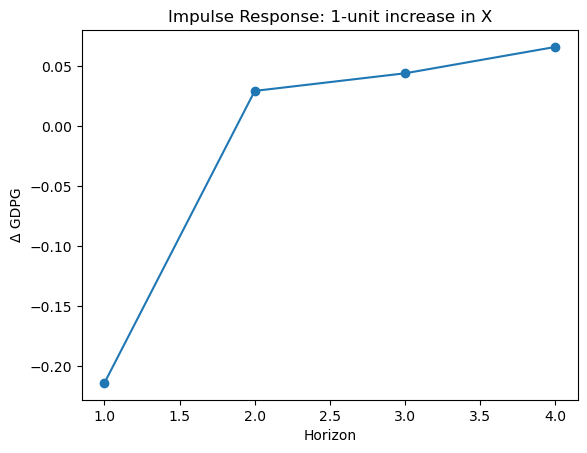


(8) Long-run effect
β_LT = -0.2733498909391405


In [44]:
# ============================================================
# Q21 — Dynamic panel in first differences + Anderson–Hsiao
# CLEAN VERSION with proper coefficient names in OLS + IV output
# (keeps pandas objects so tables show ΔGDPG, ΔX, etc.)
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from scipy.stats import chi2

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
df = df_twfe.copy()

ENTITY = "country"
TIME   = "year"

# Original variable names in your dataset
Y_raw = "ln_gdp_growth_5y"        # dependent variable
X_raw = "liquid_liabilities"      # key explanatory variable
CONTROLS_raw = ["ln_cpi", "ln_trade_openness"]

# Pretty names (match the question’s notation)
Y = "GDPG"          # GDP per head growth (or your GDPG proxy)
X = "liquid_liabilities"       # key explanatory variable (aid/GDP in the question)

# Rename columns so outputs match the question
rename_map = {Y_raw: Y, X_raw: X}
rename_map.update({c: c for c in CONTROLS_raw})  # controls keep their names (optional)
df = df.rename(columns=rename_map)

CONTROLS = CONTROLS_raw[:]  # keep control names (or rename too if you want)

# ------------------------------------------------------------
# 0. PREPARE PANEL (SORT + NUMERIC)
# ------------------------------------------------------------
df = df.sort_values([ENTITY, TIME]).copy()

vars_needed = [Y, X] + CONTROLS
for v in vars_needed:
    df[v] = pd.to_numeric(df[v], errors="coerce")

# ------------------------------------------------------------
# 1. BUILD ANDERSON–HSIAO DATASET
# ------------------------------------------------------------
# Levels lags (t-1, t-2)
df[f"{Y}_l1"] = df.groupby(ENTITY)[Y].shift(1)
df[f"{Y}_l2"] = df.groupby(ENTITY)[Y].shift(2)
df[f"{X}_l1"] = df.groupby(ENTITY)[X].shift(1)
df[f"{X}_l2"] = df.groupby(ENTITY)[X].shift(2)

# First differences
df[f"d_{Y}"] = df[Y] - df[f"{Y}_l1"]
df[f"d_{X}"] = df[X] - df[f"{X}_l1"]

# Lagged first differences (t-1)
df[f"d_{Y}_l1"] = df.groupby(ENTITY)[f"d_{Y}"].shift(1)
df[f"d_{X}_l1"] = df.groupby(ENTITY)[f"d_{X}"].shift(1)

# Controls: first differences (optional)
for c in CONTROLS:
    df[f"{c}_l1"] = df.groupby(ENTITY)[c].shift(1)
    df[f"d_{c}"] = df[c] - df[f"{c}_l1"]

needed = [
    f"d_{Y}", f"d_{Y}_l1",
    f"d_{X}", f"d_{X}_l1",
    f"{Y}_l2", f"{X}_l2"
] + [f"d_{c}" for c in CONTROLS]

df = df.dropna(subset=needed).copy()

print("Observations:", len(df))
print("Countries:", df[ENTITY].nunique())

# ------------------------------------------------------------
# 2. AUTOCORRELATION CHECK
# ------------------------------------------------------------
print("\nAutocorrelation of Δy (lag 1):")
print(df.groupby(ENTITY)[f"d_{Y}"].apply(lambda s: s.autocorr(1)).describe())

# ------------------------------------------------------------
# 3. (1) UNIVARIATE STATISTICS
# ------------------------------------------------------------
def univar(s):
    return pd.Series({
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "stderr": s.std() / np.sqrt(len(s)),
        "skew": s.skew(),
        "kurt": s.kurt(),
        "min": s.min(),
        "max": s.max(),
        "n": len(s)
    })

vars_u = [f"d_{Y}", f"d_{Y}_l1", f"d_{X}", f"d_{X}_l1", f"{Y}_l2", f"{X}_l2"]
univar_table = pd.DataFrame({v: univar(df[v]) for v in vars_u}).T
print("\n(1) Univariate statistics")
print(univar_table)

# ------------------------------------------------------------
# 4. (2) CORRELATION MATRIX
# ------------------------------------------------------------
corr_vars = [f"d_{Y}_l1", f"d_{X}", f"d_{X}_l1", f"{Y}_l2", f"{X}_l2"]
print("\n(2) Correlation matrix")
print(df[corr_vars].corr())

# ------------------------------------------------------------
# 5. (3) PANEL UNIT ROOT (FISHER–ADF)
# ------------------------------------------------------------
def fisher_adf(panel, var, entity_col, maxlag=1, regression="c", autolag=None, p_floor=1e-16):
    pvals = []
    used = 0
    skipped = 0

    for ent, g in panel.groupby(entity_col):
        s = g[var].dropna().values
        if len(s) <= maxlag + 2:
            skipped += 1
            continue
        try:
            res = adfuller(s, maxlag=maxlag, regression=regression, autolag=autolag)
            p = float(res[1])
            p = max(p, p_floor)  # avoid log(0)
            pvals.append(p)
            used += 1
        except Exception:
            skipped += 1
            continue

    if used == 0:
        return np.nan, np.nan, {"used": 0, "skipped": skipped}

    fisher_stat = -2.0 * np.sum(np.log(pvals))
    df_chi = 2 * used
    pval = chi2.sf(fisher_stat, df_chi)

    meta = {"used": used, "skipped": skipped, "df": df_chi, "min_p": min(pvals), "max_p": max(pvals)}
    return fisher_stat, pval, meta

print("(3) Fisher-ADF tests")
stat_y, p_y, meta_y = fisher_adf(df, f"d_{Y}", entity_col=ENTITY, maxlag=1, regression="c", autolag=None)
stat_x, p_x, meta_x = fisher_adf(df, f"d_{X}", entity_col=ENTITY, maxlag=1, regression="c", autolag=None)

print("Δy:", (stat_y, p_y), meta_y["used"], "entities used,", meta_y["skipped"], "skipped")
print("Δx:", (stat_x, p_x), meta_x["used"], "entities used,", meta_x["skipped"], "skipped")

# ------------------------------------------------------------
# 6. (4) OLS FD–ARDL
#   ΔGDPG_it = βy ΔGDPG_it-1 + β1 ΔX_it + β2 ΔX_it-1 + ΔControls_it + u_it
# ------------------------------------------------------------
y_ols = df[f"d_{Y}"]

X_ols = df[[f"d_{Y}_l1", f"d_{X}", f"d_{X}_l1"] + [f"d_{c}" for c in CONTROLS]].copy()

# Rename columns to match the question
X_ols = X_ols.rename(columns={
    f"d_{Y}_l1": f"Δ{Y}_t-1",
    f"d_{X}":    f"Δ({X})_t",
    f"d_{X}_l1": f"Δ({X})_t-1",
    **{f"d_{c}": f"Δ{c}_t" for c in CONTROLS}
})

X_ols = sm.add_constant(X_ols)

ols = sm.OLS(y_ols, X_ols).fit(cov_type="HC1")

print("\n(4) OLS FD–ARDL")
print(ols.summary())

# ------------------------------------------------------------
# 7. (5) ANDERSON–HSIAO IV (IV-2SLS)
#   Endogenous: ΔGDPG_{t-1}, ΔX_{t-1}
#   Instruments in LEVELS: GDPG_{t-2}, X_{t-2}
# ------------------------------------------------------------
dep = df[f"d_{Y}"].copy()

# exogenous regressors (include ΔX_t + Δcontrols_t)
exog = df[[f"d_{X}"] + [f"d_{c}" for c in CONTROLS]].copy()
exog = exog.rename(columns={
    f"d_{X}": f"Δ({X})_t",
    **{f"d_{c}": f"Δ{c}_t" for c in CONTROLS}
})
exog = sm.add_constant(exog)

# endogenous regressors
endog = df[[f"d_{Y}_l1", f"d_{X}_l1"]].copy()
endog = endog.rename(columns={
    f"d_{Y}_l1": f"Δ{Y}_t-1",
    f"d_{X}_l1": f"Δ({X})_t-1"
})

# instruments (levels at t-2)
instr = df[[f"{Y}_l2", f"{X}_l2"]].copy()
instr = instr.rename(columns={
    f"{Y}_l2": f"{Y}_t-2 (level)",
    f"{X}_l2": f"({X})_t-2 (level)"
})

iv = IV2SLS(dep, exog, endog, instr).fit(cov_type="robust")

print("\n(5) Anderson–Hsiao IV")
print(iv.summary)

# ------------------------------------------------------------
# 8. (6) FIRST STAGE
# ------------------------------------------------------------
print("\n(6) First-stage regressions")
print(iv.first_stage.summary)

# ------------------------------------------------------------
# 9. (7) IMPULSE RESPONSE FUNCTIONS (safe: use names, not positions)
#    βy = coeff on ΔGDPG_{t-1}
#    β1 = coeff on ΔX_t
#    β2 = coeff on ΔX_{t-1}
# ------------------------------------------------------------
beta_y_name = f"Δ{Y}_t-1"
beta_1_name = f"Δ({X})_t"
beta_2_name = f"Δ({X})_t-1"

βy = float(iv.params[beta_y_name])
β1 = float(iv.params[beta_1_name])
β2 = float(iv.params[beta_2_name])

IRF = [
    β1,
    βy * β1 + β2,
    (βy**2) * β1 + βy * β2,
    (βy**3) * β1 + (βy**2) * β2
]

irf_df = pd.DataFrame({"t": [1, 2, 3, 4], "IRF": IRF})
print("\n(7) IRFs")
print(irf_df)

plt.plot(irf_df["t"], irf_df["IRF"], marker="o")
plt.xlabel("Horizon")
plt.ylabel("Δ GDPG")
plt.title("Impulse Response: 1-unit increase in X")
plt.show()

# ------------------------------------------------------------
# 10. (8) LONG-RUN EFFECT
# ------------------------------------------------------------
β_LT = (β1 + β2) / (1 - βy)
print("\n(8) Long-run effect")
print("β_LT =", β_LT)


In [45]:
# ------------------------------------------------------------
# FIRST-STAGE DIAGNOSTICS (already estimated IV model)
# ------------------------------------------------------------

# Full first-stage regression tables
print(iv.first_stage.summary)

# Extract partial F-statistics for excluded instruments
for var, fs in iv.first_stage.items():
    print(f"\nFirst stage for endogenous variable: {var}")
    print("Partial F-statistic (excluded instruments):")
    print(fs.f_stat)

                     First Stage Estimation Results                     
                                     ΔGDPG_t-1 Δ(liquid_liabilities)_t-1
------------------------------------------------------------------------
R-squared                               0.0964                    0.0572
Partial R-squared                       0.0685                    0.0079
Shea's R-squared                        0.0447                    0.0051
Partial F-statistic                     38.629                    1.5758
P-value (Partial F-stat)             4.092e-09                    0.4548
Partial F-stat Distn                   chi2(2)                   chi2(2)
================================== ===========               ===========
const                                   0.0194                    0.0107
                                      (3.1883)                  (1.1897)
Δ(liquid_liabilities)_t                -0.0943                    0.2009
                                     (-2.2878)     

AttributeError: 'FirstStageResults' object has no attribute 'items'

In [48]:
# ------------------------------------------------------------
# FE–OLS IN LEVELS (long-T benchmark)
# ------------------------------------------------------------
df_fe = df_twfe.copy()
df_fe = df_fe.set_index([ENTITY, TIME])

# Build lags in LEVELS
df_fe["GDPG_l1"] = df_fe.groupby(level=0)["ln_gdp_growth_5y"].shift(1)
df_fe["X_l1"]    = df_fe.groupby(level=0)["liquid_liabilities"].shift(1)

fe_vars = [
    "ln_gdp_growth_5y",
    "GDPG_l1",
    "liquid_liabilities",
    "X_l1",
    "ln_cpi",
    "ln_trade_openness"
]

df_fe = df_fe[fe_vars].dropna()

fe_model = PanelOLS(
    df_fe["ln_gdp_growth_5y"],
    sm.add_constant(df_fe[[
        "GDPG_l1",
        "liquid_liabilities",
        "X_l1",
        "ln_cpi",
        "ln_trade_openness"
    ]]),
    entity_effects=True,
    time_effects=True
)

fe_res = fe_model.fit(cov_type="robust")
print(fe_res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       ln_gdp_growth_5y   R-squared:                        0.6850
Estimator:                   PanelOLS   R-squared (Between):             -1.0889
No. Observations:                2128   R-squared (Within):               0.7279
Date:                Fri, Dec 26 2025   R-squared (Overall):              0.7021
Time:                        14:29:26   Log-likelihood                    2919.8
Cov. Estimator:                Robust                                           
                                        F-statistic:                      858.88
Entities:                          16   P-value                           0.0000
Avg Obs:                       133.00   Distribution:                  F(5,1975)
Min Obs:                       133.00                                           
Max Obs:                       133.00   F-statistic (robust):             220.01
                            